# Cross-Model Detection Experiments - Arabic Abstracts Dataset

This notebook implements standardized cross-model detection experiments with save/load functionality and multiple runs support.

In [1]:
import os
import json
import shutil

os.environ["CUDA_VISIBLE_DEVICES"] = "2"
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"
os.environ["TORCH_USE_CUDA_DSA"] = "1"

In [2]:
from models.models import LitXLMRobertaModel
import pytorch_lightning as pl
from pytorch_lightning.callbacks import (
    ModelCheckpoint,
    EarlyStopping,
)

In [3]:
from models.data import ArabicAbstractsDataModule

In [4]:
import numpy as np
import pandas as pd
from tabulate import tabulate
import matplotlib.pyplot as plt


class CrossModelExperiment:
    def __init__(self, max_epochs=100, results_file=None, num_runs=10, fit_model=True):
        self.max_epochs = max_epochs
        self.num_runs = num_runs
        self.fit_model = fit_model
        self.results_file = results_file or "notebooks/Arabic_experiments/ArabicAbstractsDataset/multiple_runs/cross_model_detection_results.json"
        self.train_models = ["allam", "jais-batched", "llama-batched", "openai"]
        self.test_models = ["allam", "jais-batched", "llama-batched", "openai"]
        self.checkpoints_path = "trained_detectors/Arabic/ArabicAbstractsDataset/{train_model}AIDetector/checkpoints"
        
        # Load existing results
        self.all_results = self._load_results()
        
        print(f"Initialized CrossModelExperiment with {self.num_runs} runs each")
        print(f"Results will be saved to: {self.results_file}")
        
    def _load_results(self):
        """Load existing results from JSON file."""
        if os.path.exists(self.results_file):
            print(f"Loading existing results from {self.results_file}")
            with open(self.results_file, 'r') as f:
                return json.load(f)
        else:
            print(f"No existing results found. Starting fresh.")
            return {}
    
    def _save_results(self):
        """Save current results to JSON file."""
        with open(self.results_file, 'w') as f:
            json.dump(self.all_results, f, indent=2)
        print(f"Results saved to {self.results_file}")
    
    def _get_callbacks(self, train_model, run_number):
        """Get callbacks for training."""
        early_stopping = EarlyStopping(
            monitor="val_loss",
            min_delta=0.0,
            patience=3,
            verbose=True,
            mode="min",
        )
        
        checkpoint_dir = self.checkpoints_path.format(train_model=train_model.title()) + f"/run_{run_number}"
        checkpoint = ModelCheckpoint(
            monitor="val_loss",
            dirpath=checkpoint_dir,
            filename="best-checkpoint",
            save_top_k=1,
            mode="min",
        )
        
        return [early_stopping, checkpoint], checkpoint_dir
    
    def _test_on_model(self, trainer, model, test_model, train_model, checkpoint_path):
        """Test the model on a specific test dataset."""
        # Load the best checkpoint
        model = LitXLMRobertaModel.load_from_checkpoint(checkpoint_path + '/best-checkpoint.ckpt')
        
        # Setup test data
        test_datamodule = ArabicAbstractsDataModule(models=[test_model])
        test_datamodule.setup()
        
        # Run test
        model.eval()
        results = trainer.test(model, test_datamodule.test_dataloader())[0]
        return {
            'accuracy': results['test_acc'],
            'precision': results['test_precision'],
            'recall': results['test_recall'],
            'f1': results['test_f1'],
            'loss': results['test_loss']
        }
    
    def run_single_experiment(self, train_model, run_number):
        """Run a single experiment (one train model, test on all models)."""
        print(f"\n{'='*60}")
        print(f"Running {train_model} - Run {run_number + 1}/{self.num_runs}")
        print(f"{'='*60}")
        
        # Initialize components
        model = LitXLMRobertaModel()
        train_datamodule = ArabicAbstractsDataModule(models=[train_model])
        train_datamodule.setup()
        
        callbacks, checkpoint_dir = self._get_callbacks(train_model, run_number)
        trainer = pl.Trainer(
            devices=1,
            max_epochs=self.max_epochs,
            accelerator="auto",
            val_check_interval=0.25,
            check_val_every_n_epoch=1,
            callbacks=callbacks,
        )
        
        # Train the model
        if self.fit_model:
            model.train()
            print(f"Training on {train_model} data...")
            trainer.fit(model, train_datamodule)
            print(f"Training completed. Checkpoint saved to: {checkpoint_dir}")
        
        # Test on all models
        results = {}
        for test_model in self.test_models:
            model.eval()
            print(f"Testing on {test_model} data...")
            try:
                results[test_model] = self._test_on_model(trainer, model, test_model, train_model, checkpoint_dir)
                print(f"  Accuracy: {results[test_model]['accuracy']:.4f}")
            except Exception as e:
                print(f"  Error testing on {test_model}: {str(e)}")
                results[test_model] = {'error': str(e)}
        shutil.rmtree(checkpoint_dir, ignore_errors=True)
        return results
    
    def run_all_experiments(self):
        """Run all experiments with smart resume capability."""
        total_experiments = len(self.train_models) * self.num_runs
        completed_experiments = 0
        
        # Count completed experiments
        for train_model in self.train_models:
            if train_model in self.all_results:
                completed_experiments += len(self.all_results[train_model])
        
        print(f"Progress: {completed_experiments}/{total_experiments} experiments completed")
        
        for train_model in self.train_models:
            # Initialize model results if not exists
            if train_model not in self.all_results:
                self.all_results[train_model] = []
            
            # Check how many runs are already completed for this model
            completed_runs = len(self.all_results[train_model])
            
            if completed_runs >= self.num_runs:
                print(f"\n{train_model}: All {self.num_runs} runs already completed. Skipping.")
                continue
            
            print(f"\n{train_model}: {completed_runs}/{self.num_runs} runs completed. Continuing from run {completed_runs + 1}.")
            
            # Run remaining experiments
            for run_number in range(completed_runs, self.num_runs):
                try:
                    results = self.run_single_experiment(train_model, run_number)
                    
                    # Save results immediately after each run
                    self.all_results[train_model].append(results)
                    self._save_results()
                    
                    completed_experiments += 1
                    print(f"\nProgress: {completed_experiments}/{total_experiments} experiments completed")
                    
                except Exception as e:
                    print(f"Error in run {run_number + 1} for {train_model}: {str(e)}")
                    # Save error information
                    error_result = {test_model: {'error': str(e)} for test_model in self.test_models}
                    self.all_results[train_model].append(error_result)
                    self._save_results()
        
        print(f"\n{'='*60}")
        print("All experiments completed!")
        print(f"Results saved to: {self.results_file}")
        print(f"{'='*60}")
        
        return self.all_results
    
    def get_mean_and_std(self, data=None):
        """Calculate mean and standard deviation for all metrics."""
        if data is None:
            data = self.all_results
        
        results = {}
        metrics = ['accuracy', 'precision', 'recall', 'f1']
        
        for train_model in data.keys():
            results[train_model] = {}
            
            for test_model in self.test_models:
                results[train_model][test_model] = {}
                
                for metric in metrics:
                    values = []
                    for run in data[train_model]:
                        if test_model in run and metric in run[test_model] and 'error' not in run[test_model]:
                            values.append(run[test_model][metric] * 100)  # Convert to percentage
                    
                    if values:
                        mean_val = np.mean(values)
                        std_val = np.std(values, ddof=1) if len(values) > 1 else 0.0
                        
                        results[train_model][test_model][metric] = {
                            'mean': mean_val,
                            'std': std_val,
                            'count': len(values)
                        }
                    else:
                        results[train_model][test_model][metric] = {
                            'mean': 0.0,
                            'std': 0.0,
                            'count': 0
                        }
        
        return results
    
    def create_summary_table(self, with_std=True):
        """Create a formatted summary table of results."""
        mean_std_data = self.get_mean_and_std()
        
        summary_data = []
        metrics = ['accuracy', 'precision', 'recall', 'f1']
        
        # Header
        header = ['Metric', 'Train → Test', 'ALLaM', 'Jais', 'Llama', 'OpenAI']
        
        model_display_names = {
            'allam': 'ALLaM',
            'jais-batched': 'Jais',
            'llama-batched': 'Llama', 
            'openai': 'OpenAI'
        }
        
        for metric in metrics:
            for i, train_model in enumerate(self.train_models):
                if i == 0:  # First row for this metric
                    row = [metric.capitalize(), model_display_names[train_model]]
                else:
                    row = ['', model_display_names[train_model]]
                
                for test_model in self.test_models:
                    mean_val = mean_std_data[train_model][test_model][metric]['mean']
                    std_val = mean_std_data[train_model][test_model][metric]['std']
                    count = mean_std_data[train_model][test_model][metric]['count']
                    
                    if count == 0:
                        formatted_value = "N/A"
                    elif with_std and std_val > 0 and count > 1:
                        formatted_value = f"{mean_val:.2f} ± {std_val:.2f}"
                    else:
                        formatted_value = f"{mean_val:.2f}"
                    
                    row.append(formatted_value)
                
                summary_data.append(row)
        
        return tabulate(summary_data, headers=header, tablefmt='grid', stralign='center')
    
    def display_results(self):
        """Display comprehensive results."""
        print("\n" + "="*80)
        print("CROSS-MODEL DETECTION RESULTS SUMMARY")
        print("="*80)
        
        # Show completion status
        print(f"\nExperiment Status:")
        print(f"Target runs per model: {self.num_runs}")
        for train_model in self.train_models:
            completed = len(self.all_results.get(train_model, []))
            print(f"  {train_model}: {completed}/{self.num_runs} runs completed")
        
        # Show results table
        print(f"\nResults Table:")
        print(self.create_summary_table())
        
        print(f"\nResults saved to: {self.results_file}")
        print("="*80)

In [5]:
# Initialize the experiment
experiment = CrossModelExperiment(
    max_epochs=100,
    num_runs=10,
    fit_model=True,  # Set to False to skip training and only test
    results_file="notebooks/Arabic_experiments/ArabicAbstractsDataset/multiple_runs/cross_model_detection_results.json"
)

Loading existing results from notebooks/Arabic_experiments/ArabicAbstractsDataset/multiple_runs/cross_model_detection_results.json
Initialized CrossModelExperiment with 10 runs each
Results will be saved to: notebooks/Arabic_experiments/ArabicAbstractsDataset/multiple_runs/cross_model_detection_results.json


In [6]:
# Run all experiments with smart resume
results = experiment.run_all_experiments()

Progress: 4/40 experiments completed

allam: 1/10 runs completed. Continuing from run 2.

Running allam - Run 2/10


Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at xlm-roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


/home/majed_alshaibani/Projects/arabic-text-detection/.venv/lib/python3.10/site-packages/lightning_fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python3 /home/majed_alshaibani/Projects/arabic-text-detecti ...
GPU available: True (cuda), used: True


TPU available: False, using: 0 TPU cores


HPU available: False, using: 0 HPUs


...

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [2]


Testing: |                                                                                                    …

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test_acc            0.9994142055511475
         test_f1            0.9995640516281128
        test_loss          0.0009619605843909085
     test_precision          0.999147891998291
       test_recall                  1.0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


  Accuracy: 0.9994


Results saved to notebooks/Arabic_experiments/ArabicAbstractsDataset/multiple_runs/cross_model_detection_results.json

Progress: 40/40 experiments completed

All experiments completed!
Results saved to: notebooks/Arabic_experiments/ArabicAbstractsDataset/multiple_runs/cross_model_detection_results.json


In [7]:
# Display results summary table
experiment.display_results()


CROSS-MODEL DETECTION RESULTS SUMMARY

Experiment Status:
Target runs per model: 10
  allam: 10/10 runs completed
  jais-batched: 10/10 runs completed
  llama-batched: 10/10 runs completed
  openai: 10/10 runs completed

Results Table:
+-----------+----------------+--------------+--------------+--------------+--------------+
|  Metric   |  Train → Test  |    ALLaM     |     Jais     |    Llama     |    OpenAI    |
+===========+================+==============+==============+==============+==============+
| Accuracy  |     ALLaM      | 99.81 ± 0.19 | 98.00 ± 0.53 | 95.32 ± 1.04 | 99.25 ± 0.99 |
+-----------+----------------+--------------+--------------+--------------+--------------+
|           |      Jais      | 99.66 ± 0.14 | 99.44 ± 0.11 | 96.70 ± 0.68 | 99.68 ± 0.13 |
+-----------+----------------+--------------+--------------+--------------+--------------+
|           |     Llama      | 99.26 ± 0.48 | 98.63 ± 0.30 | 98.16 ± 0.30 | 99.27 ± 0.49 |
+-----------+----------------+-----

In [8]:
def plot_cross_model_performance(results_file="notebooks/Arabic_experiments/ArabicAbstractsDataset/multiple_runs/cross_model_detection_results.json"):
    """Plot cross-model performance with error bars."""
    
    # Load results
    if not os.path.exists(results_file):
        print(f"Results file {results_file} not found. Run experiments first.")
        return
    
    with open(results_file, 'r') as f:
        data = json.load(f)
    
    # Create experiment instance to use helper methods
    exp = CrossModelExperiment()
    exp.all_results = data
    mean_std_data = exp.get_mean_and_std(data)
    
    # Prepare data for plotting
    train_models = list(data.keys())
    test_models = ['allam', 'jais-batched', 'llama-batched', 'openai']
    model_display_names = {
        'allam': 'ALLaM',
        'jais-batched': 'Jais',
        'llama-batched': 'Llama',
        'openai': 'OpenAI'
    }
    
    # Set up the plot
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    fig.suptitle('Cross-Model Detection Performance - Arabic Abstracts Dataset', 
                 fontsize=16, fontweight='bold')
    
    metrics = ['accuracy', 'precision', 'recall', 'f1']
    metric_titles = ['Accuracy (%)', 'Precision (%)', 'Recall (%)', 'F1-Score (%)']
    
    for idx, (metric, title) in enumerate(zip(metrics, metric_titles)):
        ax = axes[idx // 2, idx % 2]
        
        # Prepare data for this metric
        x_pos = np.arange(len(test_models))
        width = 0.2
        
        for i, train_model in enumerate(train_models):
            means = []
            stds = []
            
            for test_model in test_models:
                mean_val = mean_std_data[train_model][test_model][metric]['mean']
                std_val = mean_std_data[train_model][test_model][metric]['std']
                means.append(mean_val)
                stds.append(std_val)
            
            # Plot bars with error bars
            bars = ax.bar(x_pos + i * width, means, width, 
                         label=f'Trained on {model_display_names[train_model]}',
                         alpha=0.8, capsize=5)
            
            # Add error bars if std > 0
            for j, (bar, std_val) in enumerate(zip(bars, stds)):
                if std_val > 0:
                    ax.errorbar(bar.get_x() + bar.get_width()/2, bar.get_height(), 
                               yerr=std_val, fmt='none', color='black', capsize=3)
        
        # Customize the subplot
        ax.set_title(title, fontweight='bold')
        ax.set_xlabel('Test Model', fontweight='bold')
        ax.set_ylabel(title, fontweight='bold')
        ax.set_xticks(x_pos + width * 1.5)
        ax.set_xticklabels([model_display_names[model] for model in test_models])
        ax.legend(fontsize='small')
        ax.grid(True, alpha=0.3)
        ax.set_ylim(0, 105)  # Set y-limit for percentages
    
    plt.tight_layout()
    plt.show()
    
    print(f"\nPerformance visualization generated from {results_file}")


In [9]:
def plot_cross_model_performance(results_file="notebooks/Arabic_experiments/ArabicAbstractsDataset/multiple_runs/cross_model_detection_results.json"):
    """Plot cross-model performance with error bars."""
    
    # Load results
    if not os.path.exists(results_file):
        print(f"Results file {results_file} not found. Run experiments first.")
        return
    
    with open(results_file, 'r') as f:
        data = json.load(f)
    
    # Create experiment instance to use helper methods
    exp = CrossModelExperiment()
    exp.all_results = data
    mean_std_data = exp.get_mean_and_std(data)
    
    # Prepare data for plotting
    train_models = list(data.keys())
    test_models = ['allam', 'jais-batched', 'llama-batched', 'openai']
    model_display_names = {
        'allam': 'ALLaM',
        'jais-batched': 'Jais',
        'llama-batched': 'Llama',
        'openai': 'OpenAI'
    }
    
    # Set up the plot
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    fig.suptitle('Cross-Model Detection Performance - Arabic Abstracts Dataset', 
                 fontsize=16, fontweight='bold')
    
    metrics = ['accuracy', 'precision', 'recall', 'f1']
    metric_titles = ['Accuracy (%)', 'Precision (%)', 'Recall (%)', 'F1-Score (%)']
    
    for idx, (metric, title) in enumerate(zip(metrics, metric_titles)):
        ax = axes[idx // 2, idx % 2]
        
        # Prepare data for this metric
        x_pos = np.arange(len(test_models))
        width = 0.2
        
        for i, train_model in enumerate(train_models):
            means = []
            stds = []
            
            for test_model in test_models:
                mean_val = mean_std_data[train_model][test_model][metric]['mean']
                std_val = mean_std_data[train_model][test_model][metric]['std']
                means.append(mean_val)
                stds.append(std_val)
            
            # Plot bars with error bars
            bars = ax.bar(x_pos + i * width, means, width, 
                         label=f'Trained on {model_display_names[train_model]}',
                         alpha=0.8, capsize=5)
            
            # Add error bars if std > 0
            for j, (bar, std_val) in enumerate(zip(bars, stds)):
                if std_val > 0:
                    ax.errorbar(bar.get_x() + bar.get_width()/2, bar.get_height(), 
                               yerr=std_val, fmt='none', color='black', capsize=3)
        
        # Customize the subplot
        ax.set_title(title, fontweight='bold')
        ax.set_xlabel('Test Model', fontweight='bold')
        ax.set_ylabel(title, fontweight='bold')
        ax.set_xticks(x_pos + width * 1.5)
        ax.set_xticklabels([model_display_names[model] for model in test_models])
        ax.legend(fontsize='small')
        ax.grid(True, alpha=0.3)
        ax.set_ylim(0, 105)  # Set y-limit for percentages
    
    plt.tight_layout()
    plt.show()
    
    print(f"\nPerformance visualization generated from {results_file}")

Loading existing results from notebooks/Arabic_experiments/ArabicAbstractsDataset/multiple_runs/cross_model_detection_results.json
Initialized CrossModelExperiment with 10 runs each
Results will be saved to: notebooks/Arabic_experiments/ArabicAbstractsDataset/multiple_runs/cross_model_detection_results.json


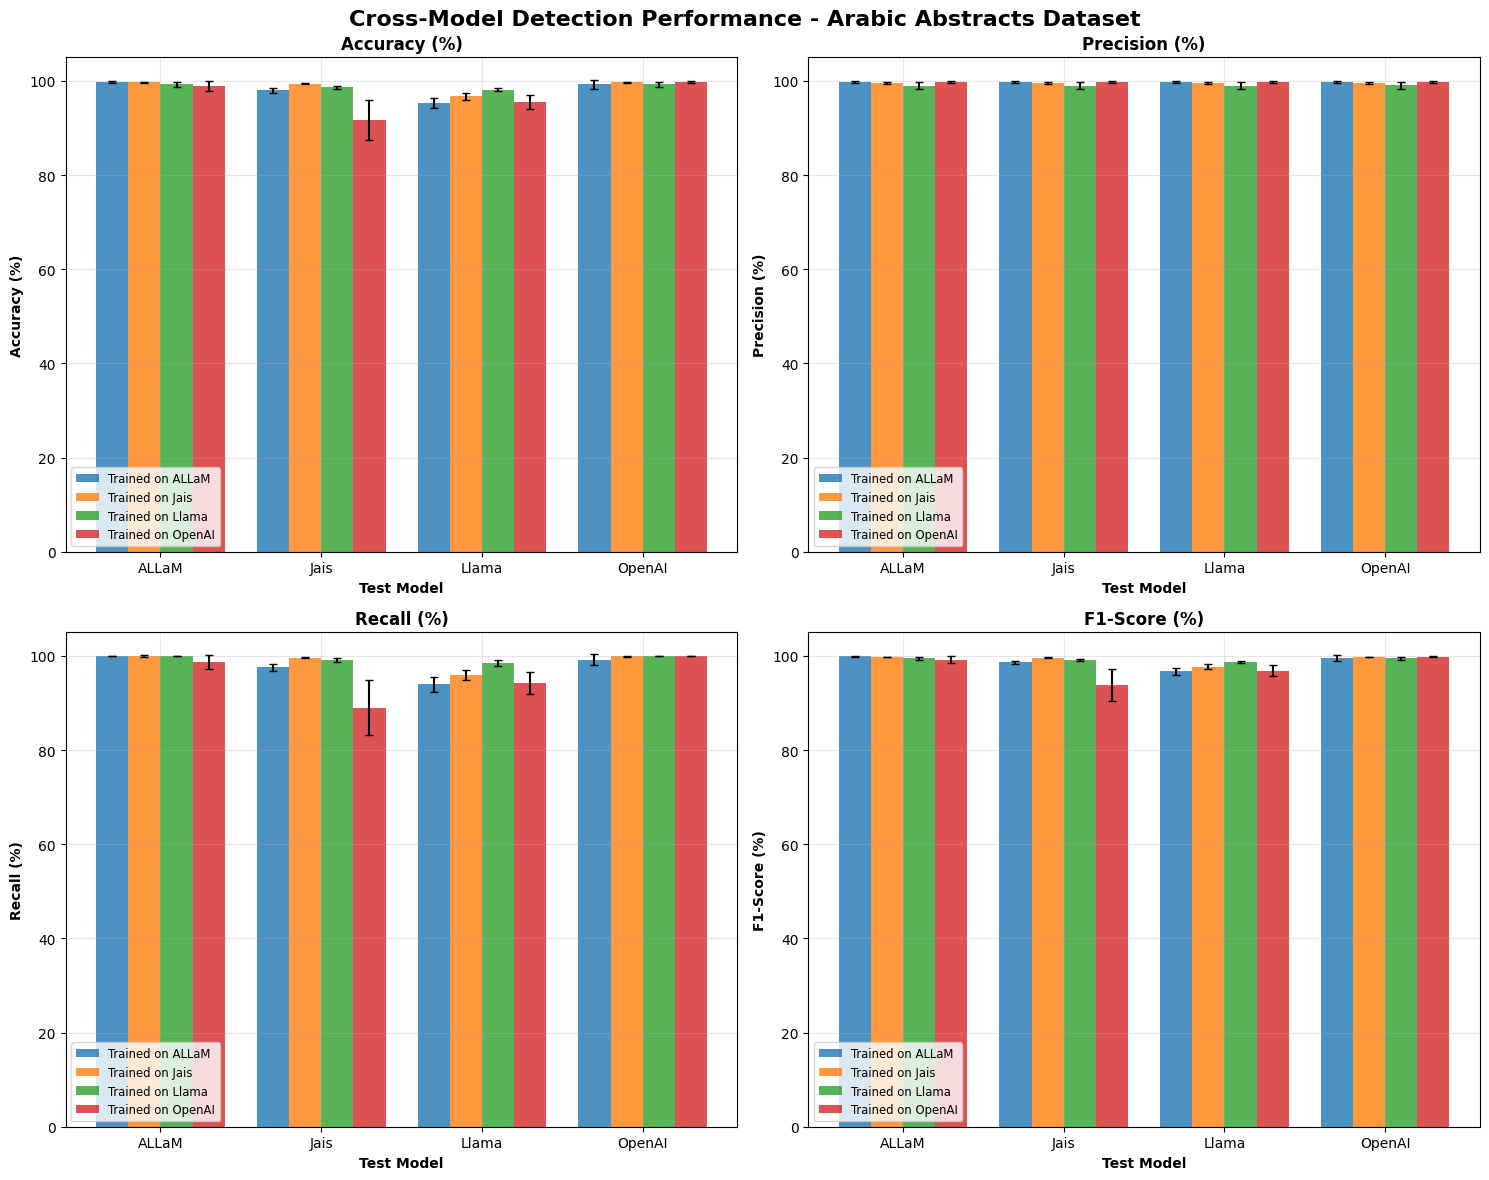


Performance visualization generated from notebooks/Arabic_experiments/ArabicAbstractsDataset/multiple_runs/cross_model_detection_results.json


In [10]:
# Generate performance plots
plot_cross_model_performance("notebooks/Arabic_experiments/ArabicAbstractsDataset/multiple_runs/cross_model_detection_results.json")